       Mean Revenue        Std Dev           Min           Max  \
80-20  1.664380e+06  113273.150549  1.342771e+06  2.045908e+06   
50-50  1.640059e+06  110694.135139  1.298748e+06  1.983797e+06   
30-70  1.622471e+06  106099.062585  1.298561e+06  2.020039e+06   
0-100  1.597298e+06  100348.018136  1.289132e+06  1.930425e+06   

       5th Percentile  95th Percentile  
80-20    1.478830e+06     1.853316e+06  
50-50    1.448736e+06     1.813902e+06  
30-70    1.439863e+06     1.790149e+06  
0-100    1.432727e+06     1.760211e+06  


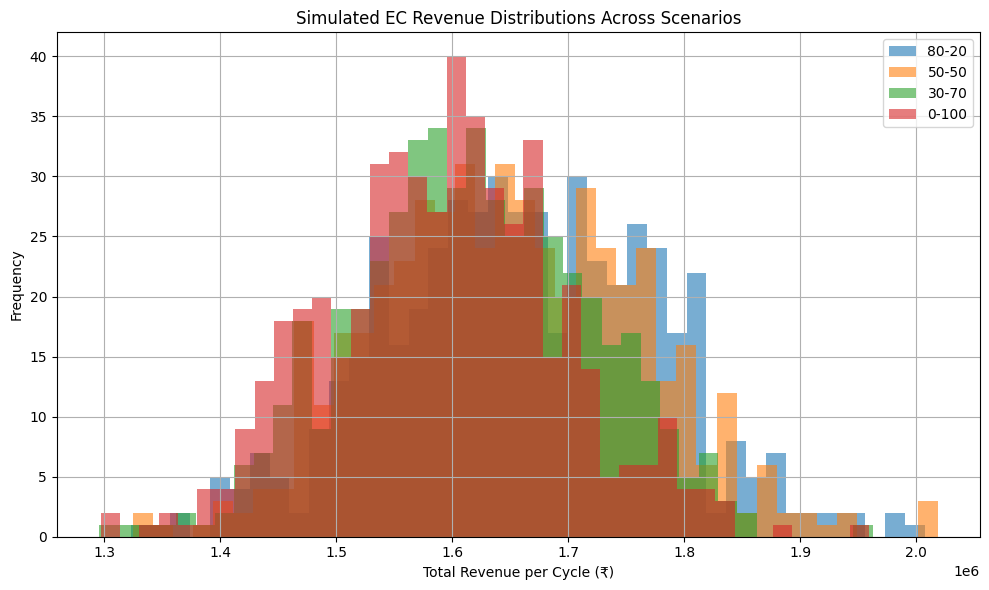

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parameters
mean_contractor = 16849
std_contractor = 11603

mean_organic = 16004
std_organic = 10475

n_ec_per_cycle = 100  # Total ECs per sales cycle
n_simulations = 1000  # How many cycles to simulate

# Define your scenarios
scenarios = {
    "80-20": (0.8, 0.2),
    "50-50": (0.5, 0.5),
    "30-70": (0.3, 0.7),
    "0-100": (0.0, 1.0)
}

results = {}

for label, (p_contract, p_organic) in scenarios.items():
    contractor_counts = int(n_ec_per_cycle * p_contract)
    organic_counts = n_ec_per_cycle - contractor_counts

    total_revenues = []
    for _ in range(n_simulations):
        contractor_revenue = np.random.normal(mean_contractor, std_contractor, contractor_counts)
        organic_revenue = np.random.normal(mean_organic, std_organic, organic_counts)
        total_revenue = contractor_revenue.sum() + organic_revenue.sum()
        total_revenues.append(total_revenue)

    results[label] = {
        "Mean Revenue": np.mean(total_revenues),
        "Std Dev": np.std(total_revenues),
        "Min": np.min(total_revenues),
        "Max": np.max(total_revenues),
        "5th Percentile": np.percentile(total_revenues, 5),
        "95th Percentile": np.percentile(total_revenues, 95)
    }

# Convert results to DataFrame
df_results = pd.DataFrame(results).T
print(df_results)

# Plotting
plt.figure(figsize=(10, 6))
for label, data in results.items():
    plt.hist(
        np.random.normal(data["Mean Revenue"], data["Std Dev"], 500),
        bins=40, alpha=0.6, label=label
    )
plt.title("Simulated EC Revenue Distributions Across Scenarios")
plt.xlabel("Total Revenue per Cycle (₹)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
